In [1]:
import os
import sys

paths = [
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/myopacus",
    "/Volumes/Users/shegao_t1/DP_Research/Personal_DP_Personal_FL/rpdp_fl/torchdp",
    "/your/path/rpdp_fl/experiments",
]

for p in paths:
    if p not in sys.path:
        sys.path.append(p)

# Optional: also update environment variable
os.environ["PYTHONPATH"] = ":".join(sys.path)

In [2]:
from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "mnist"   # change to "fashion_mnist" when needed

all_results = []

data_types = [
    "iid_10",
    "niid_dir_5",
    "niid_10_5",
    "niid_dir_1",
    "niid_10_2",
]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_unidp_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))


/Volumes/Users/shegao_t1/.conda/envs/rpdp/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading: ./fed_mnist/iid_10/ditto/iid_10_results_ditto_unidp_mnist.csv
Loading: ./fed_mnist/niid_dir_5/ditto/niid_dir_5_results_ditto_unidp_mnist.csv
Loading: ./fed_mnist/niid_10_5/ditto/niid_10_5_results_ditto_unidp_mnist.csv
Loading: ./fed_mnist/niid_dir_1/ditto/niid_dir_1_results_ditto_unidp_mnist.csv
Loading: ./fed_mnist/niid_10_2/ditto/niid_10_2_results_ditto_unidp_mnist.csv


This graphs plots comparing Vanilla, Ditto w Global DP, and Ditto w Local DP
for one value of lambda and num_personal_steps

Epsilons found: [0.0, 0.1, 0.5, 1.0, 4.0, 8.0, 16.0]


/tmp/ipykernel_1072644/813274065.py:120: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale('log')


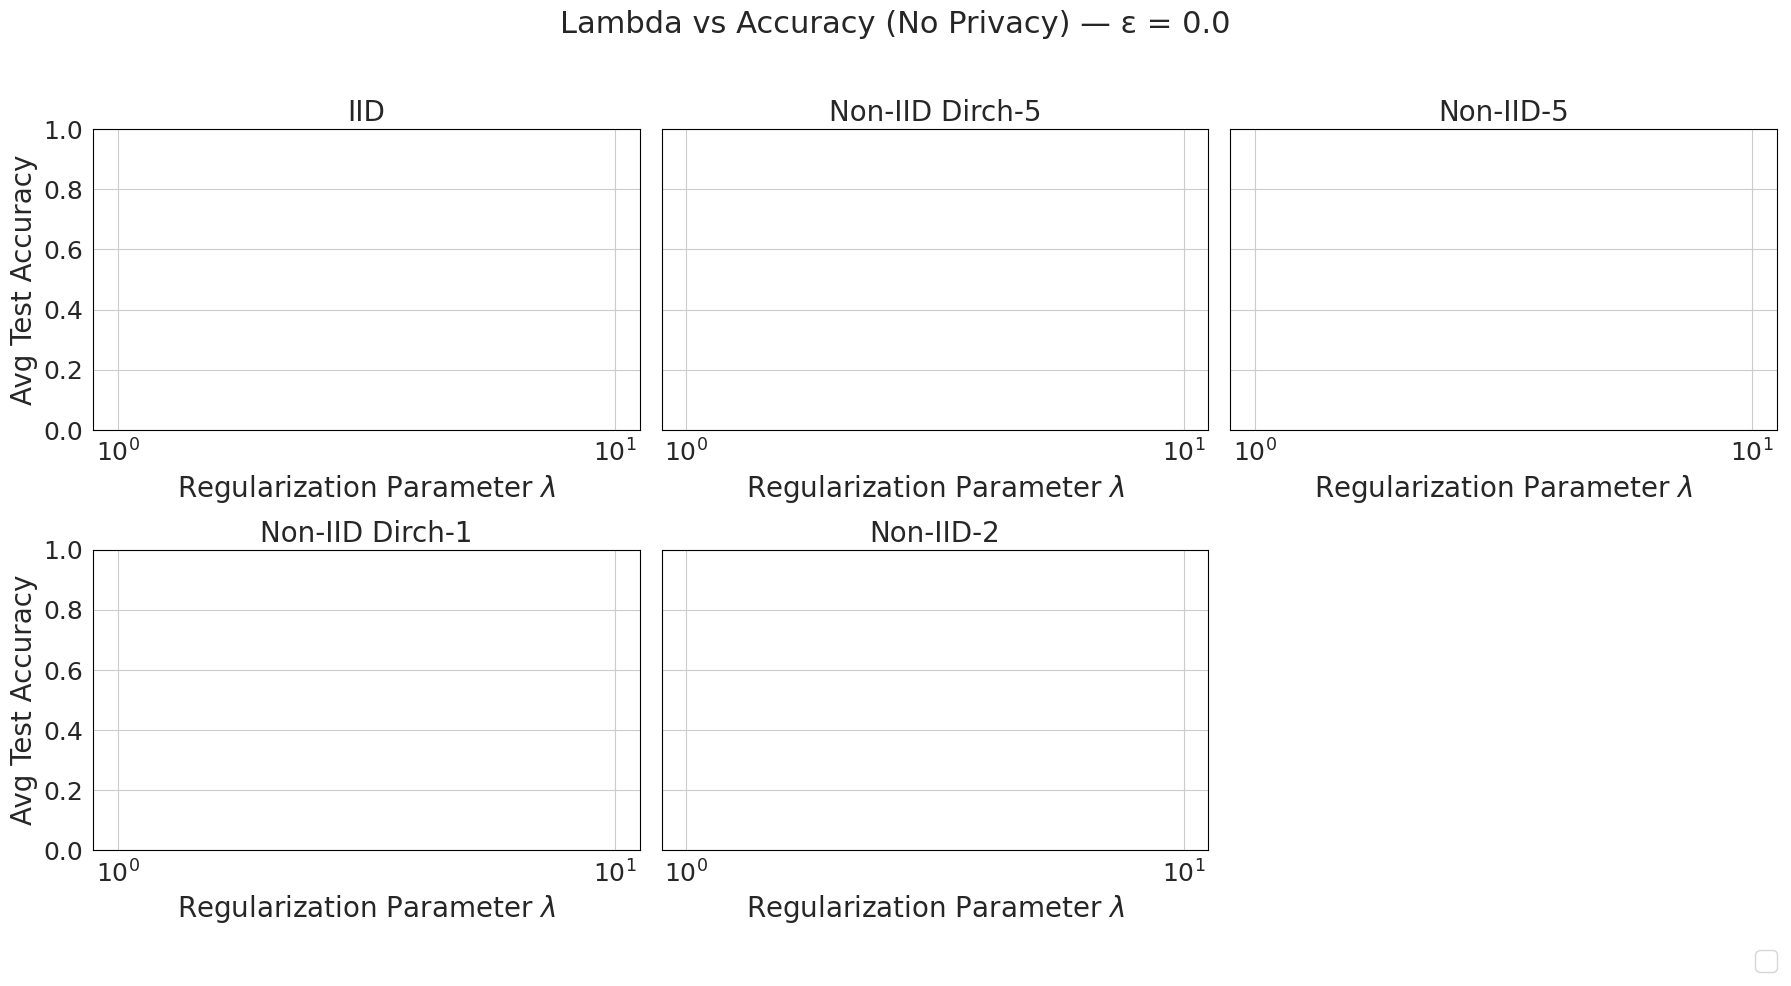

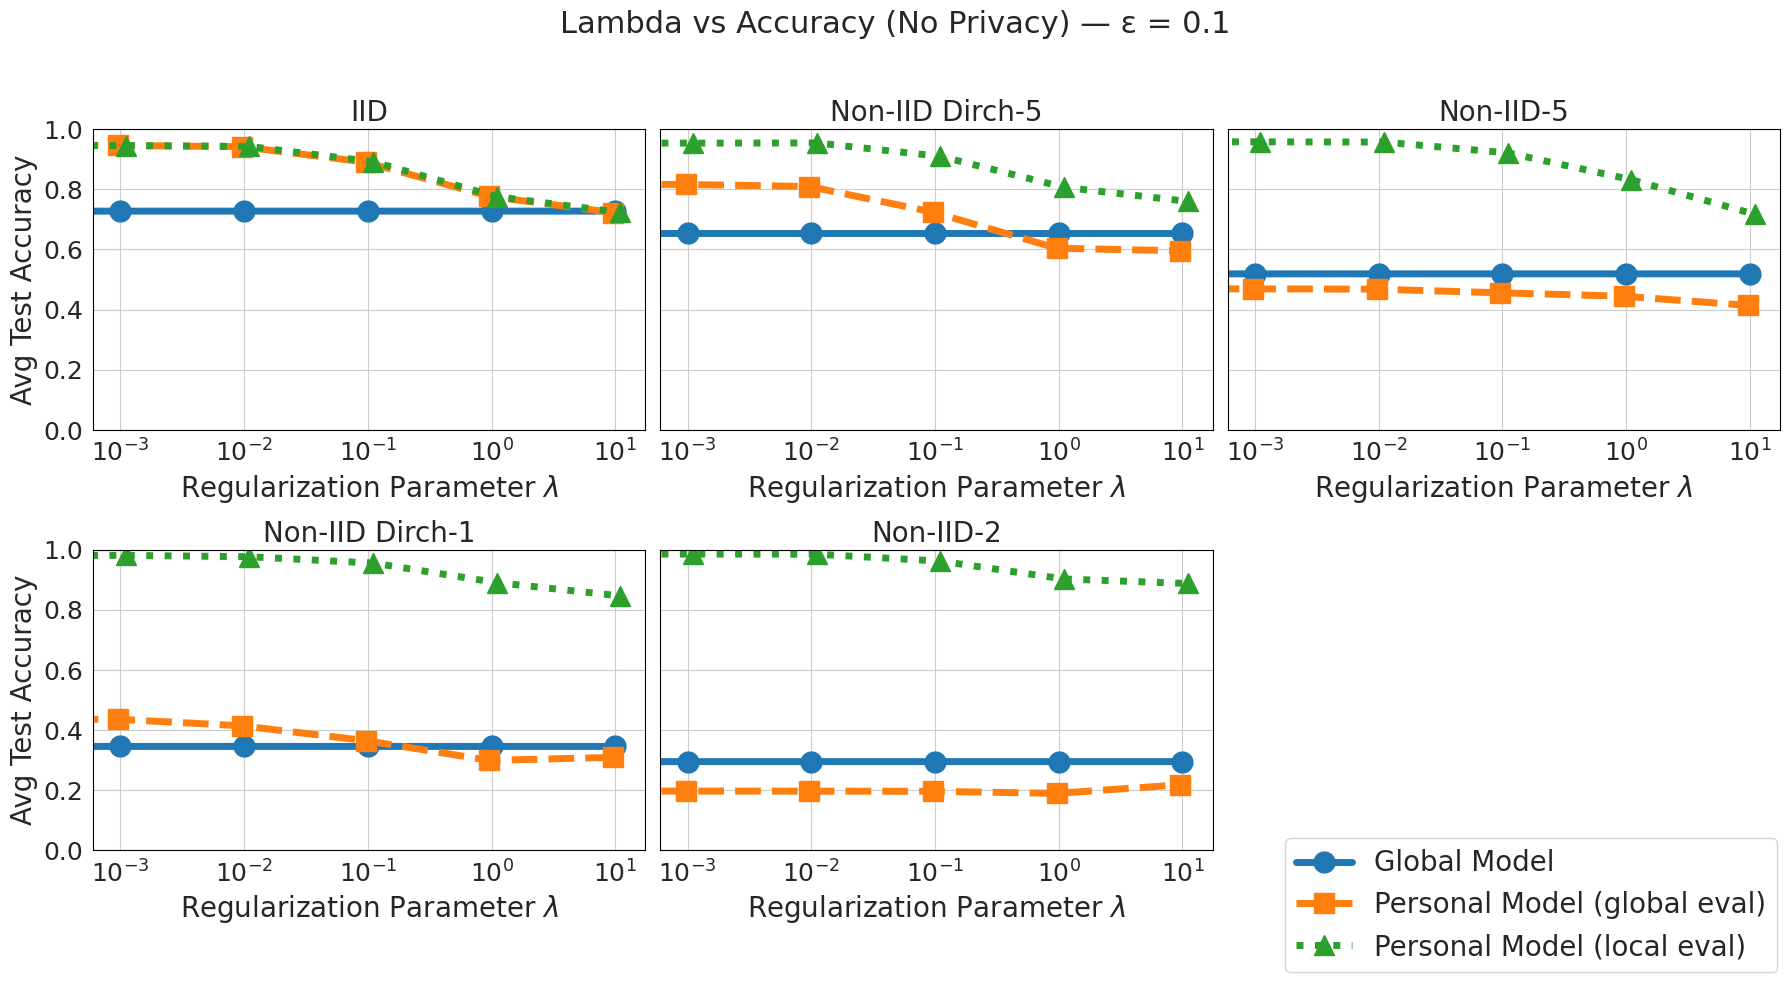

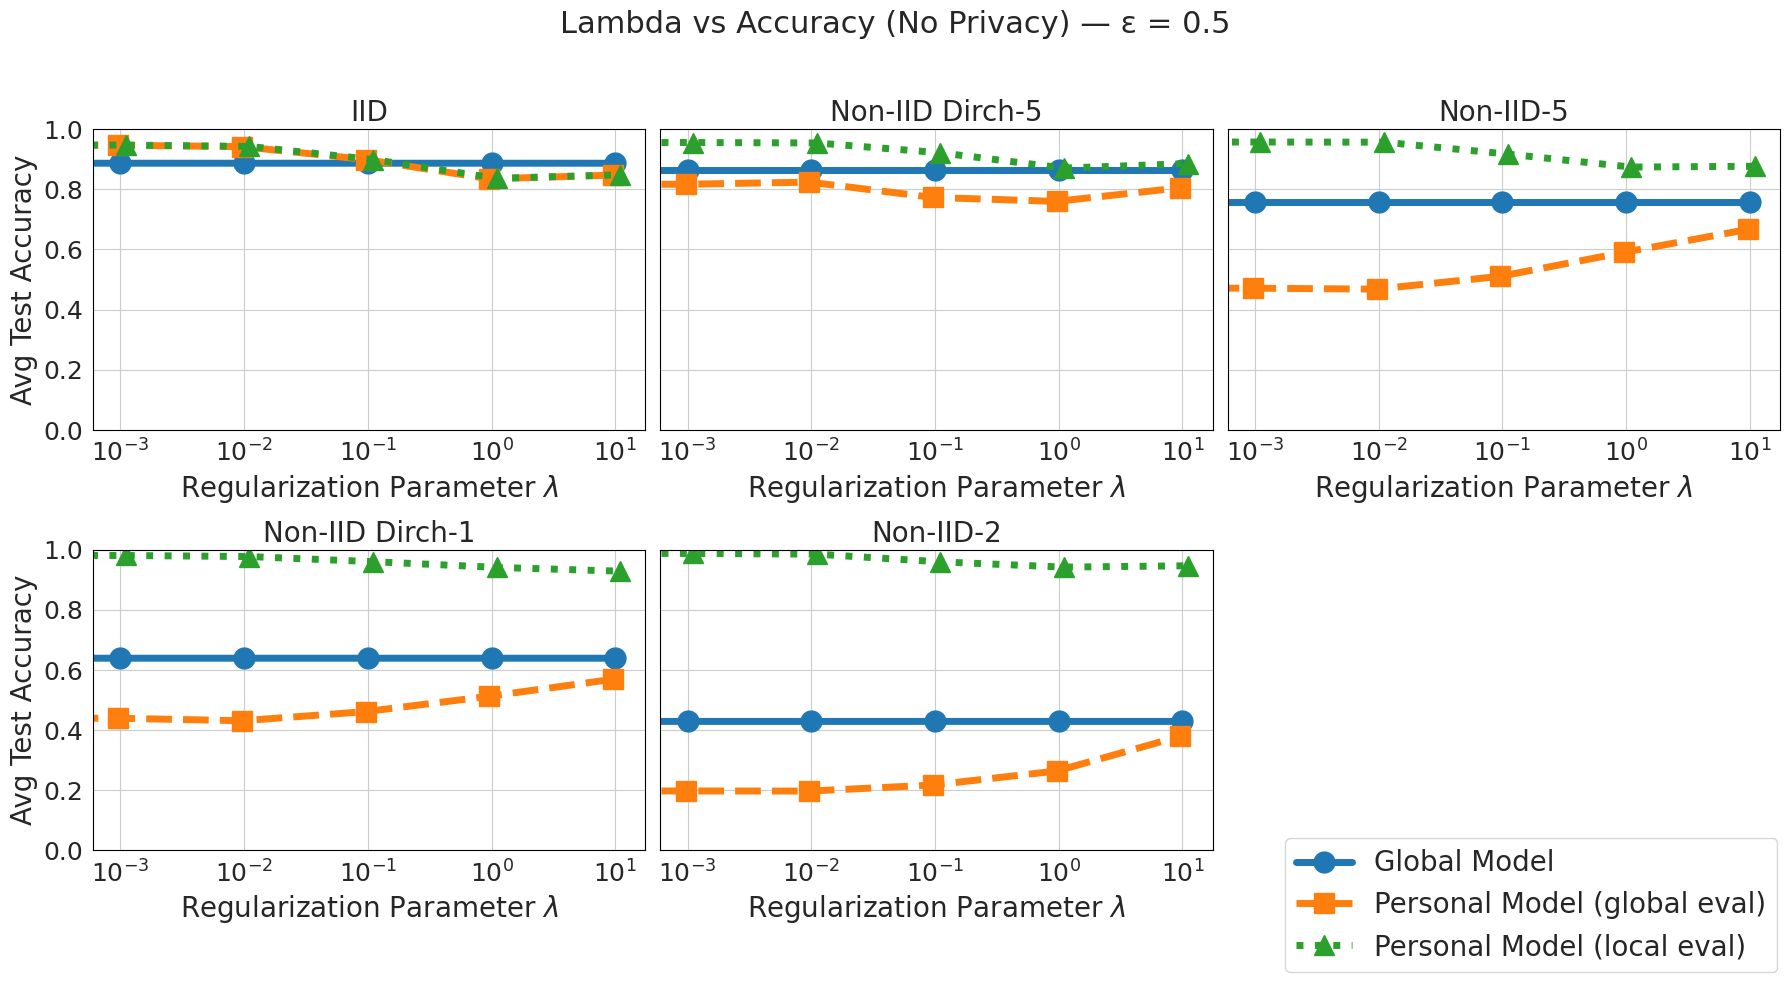

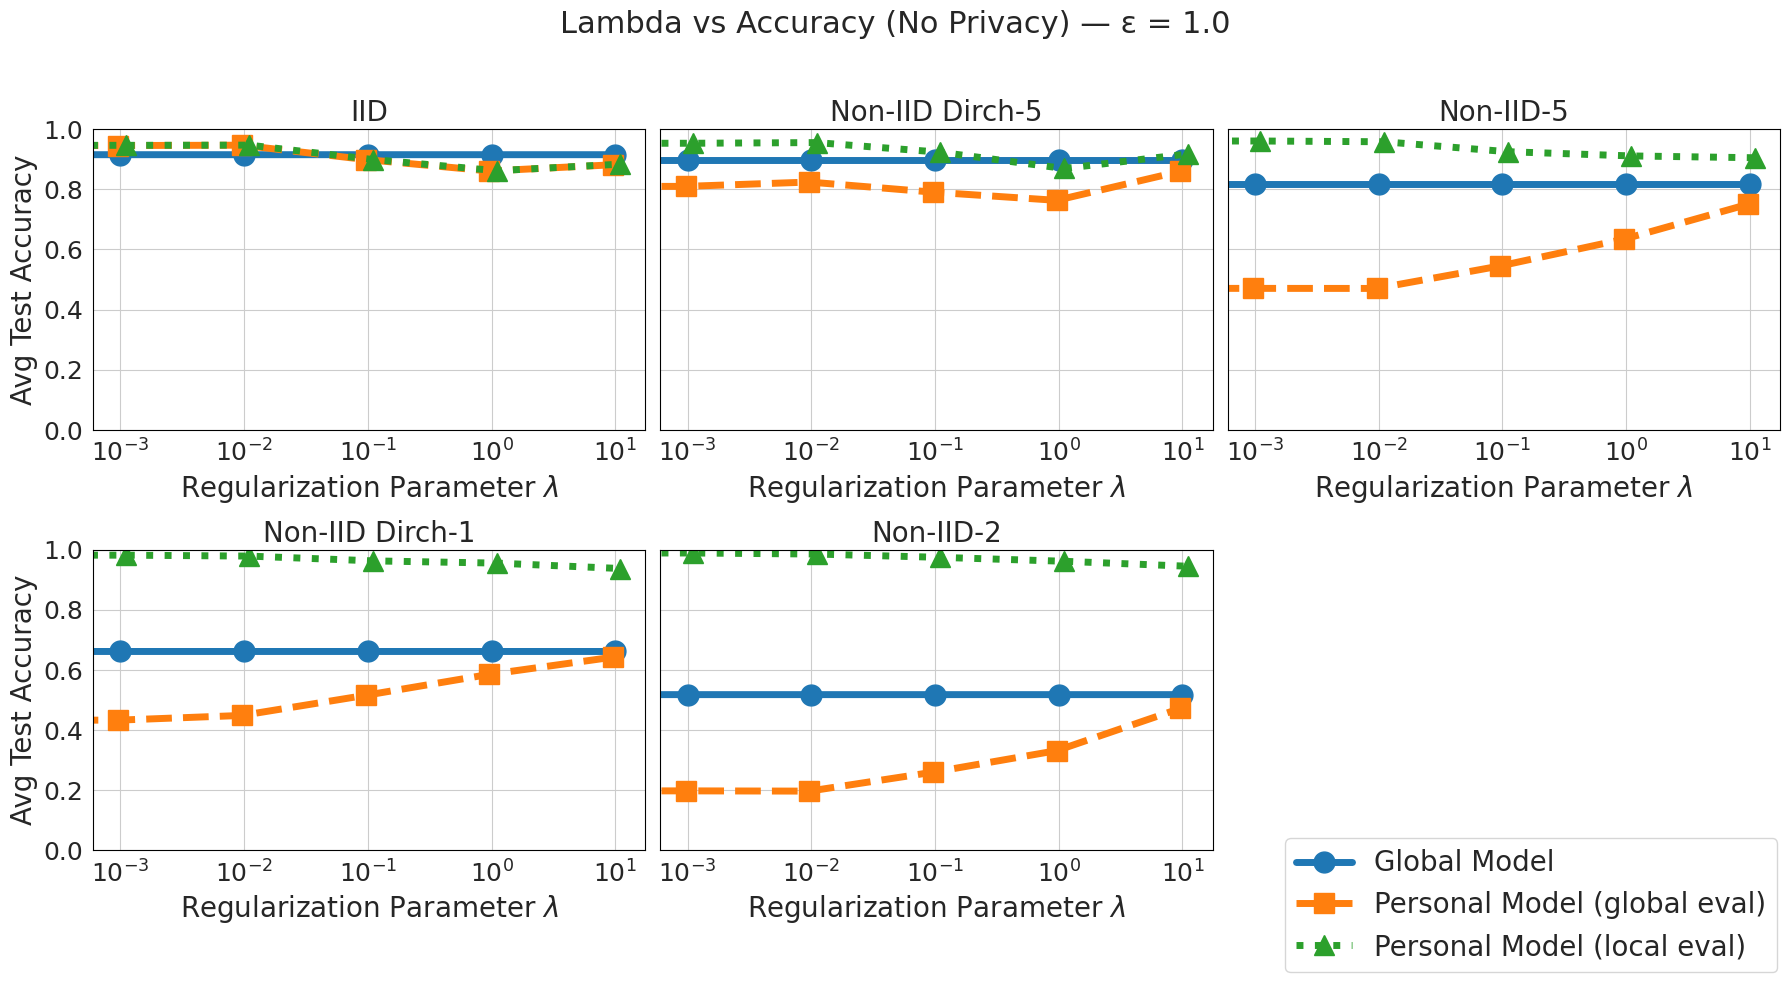

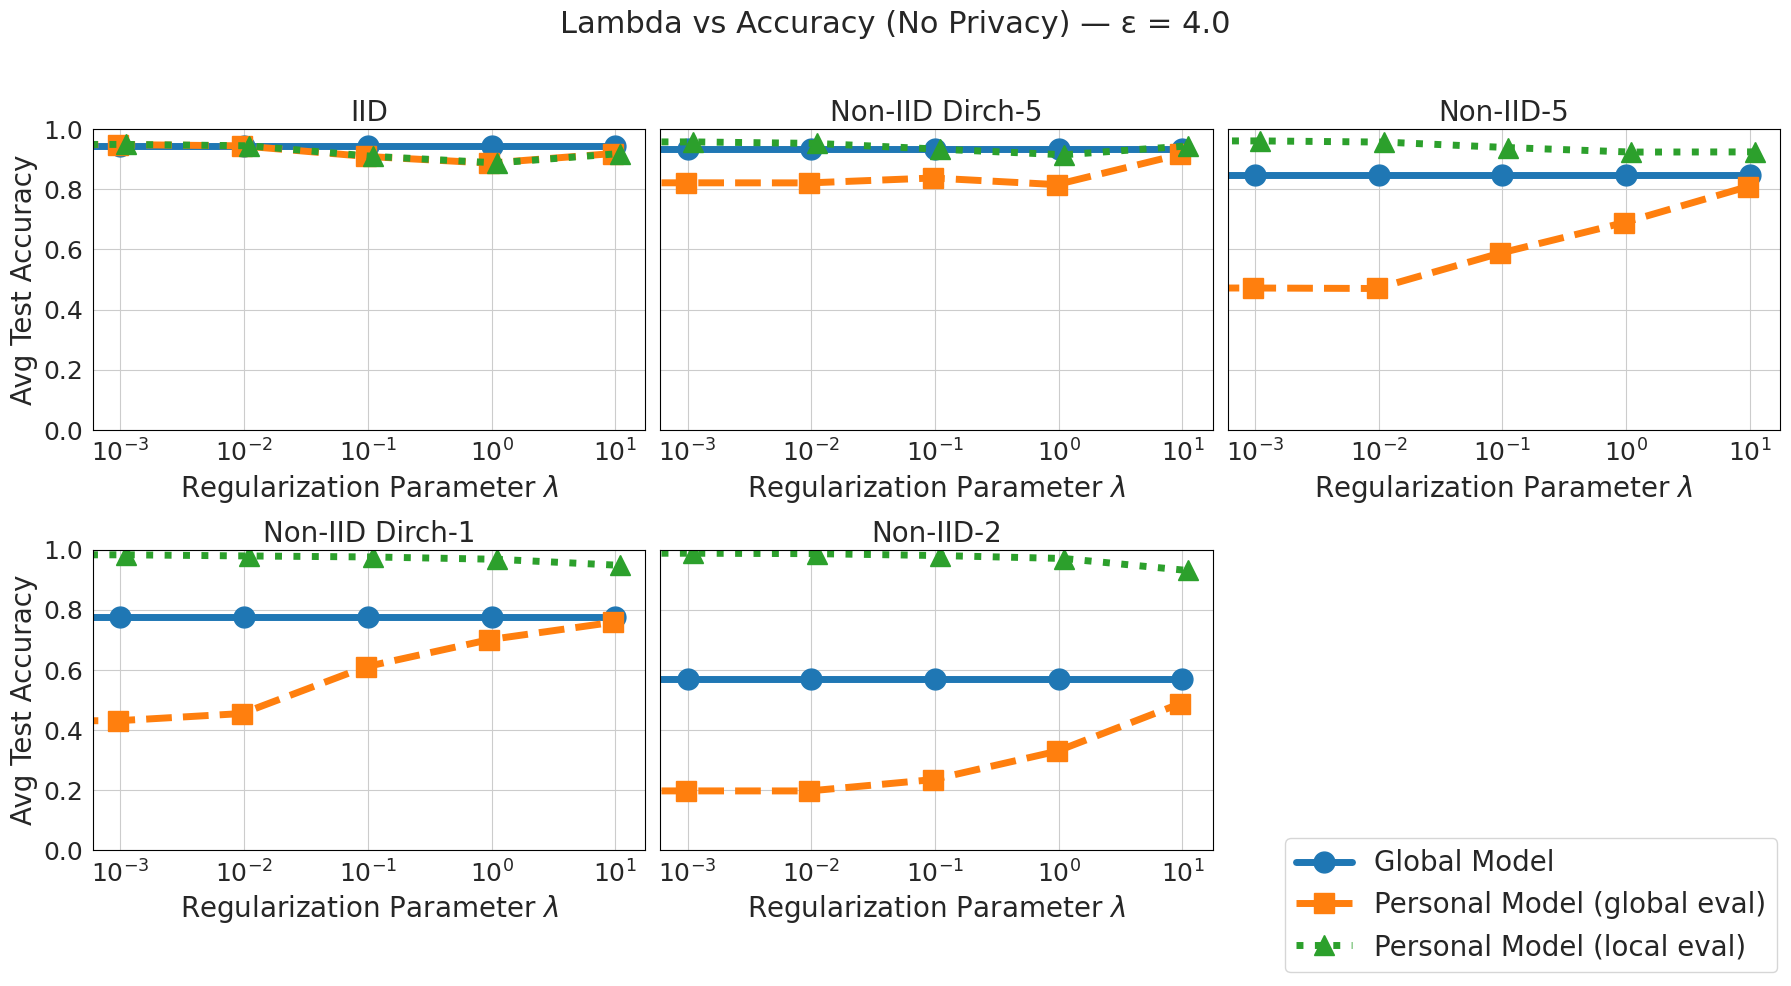

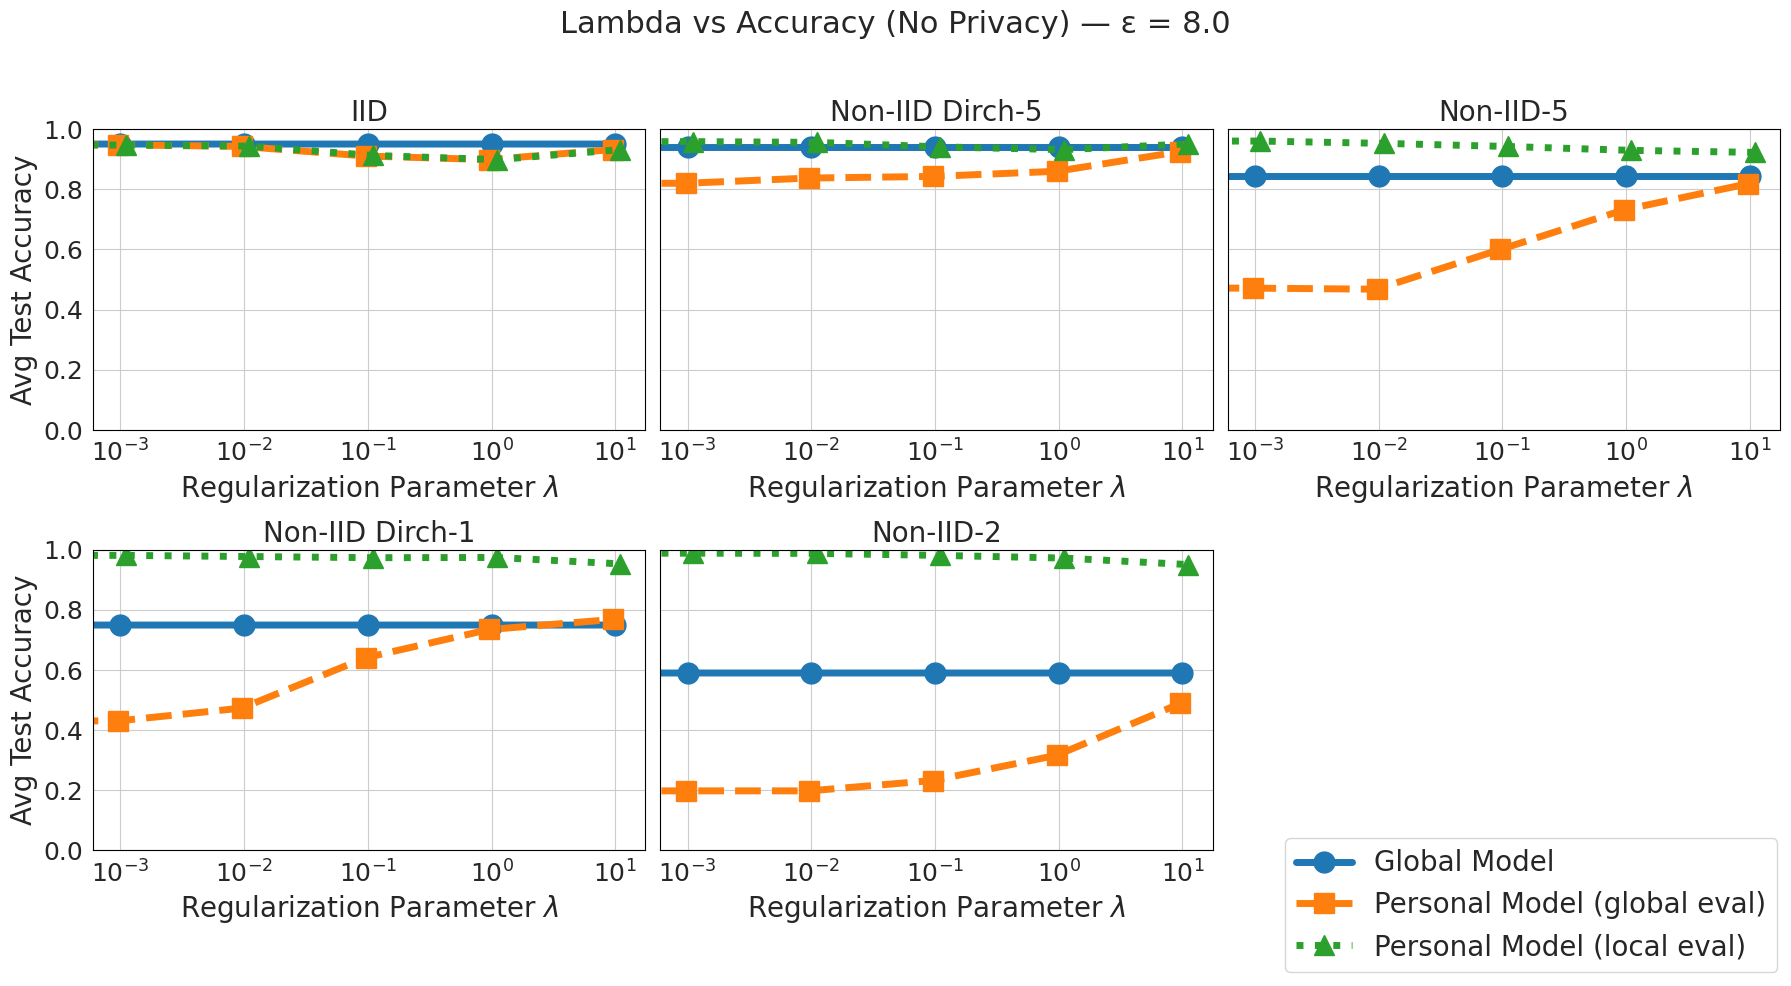

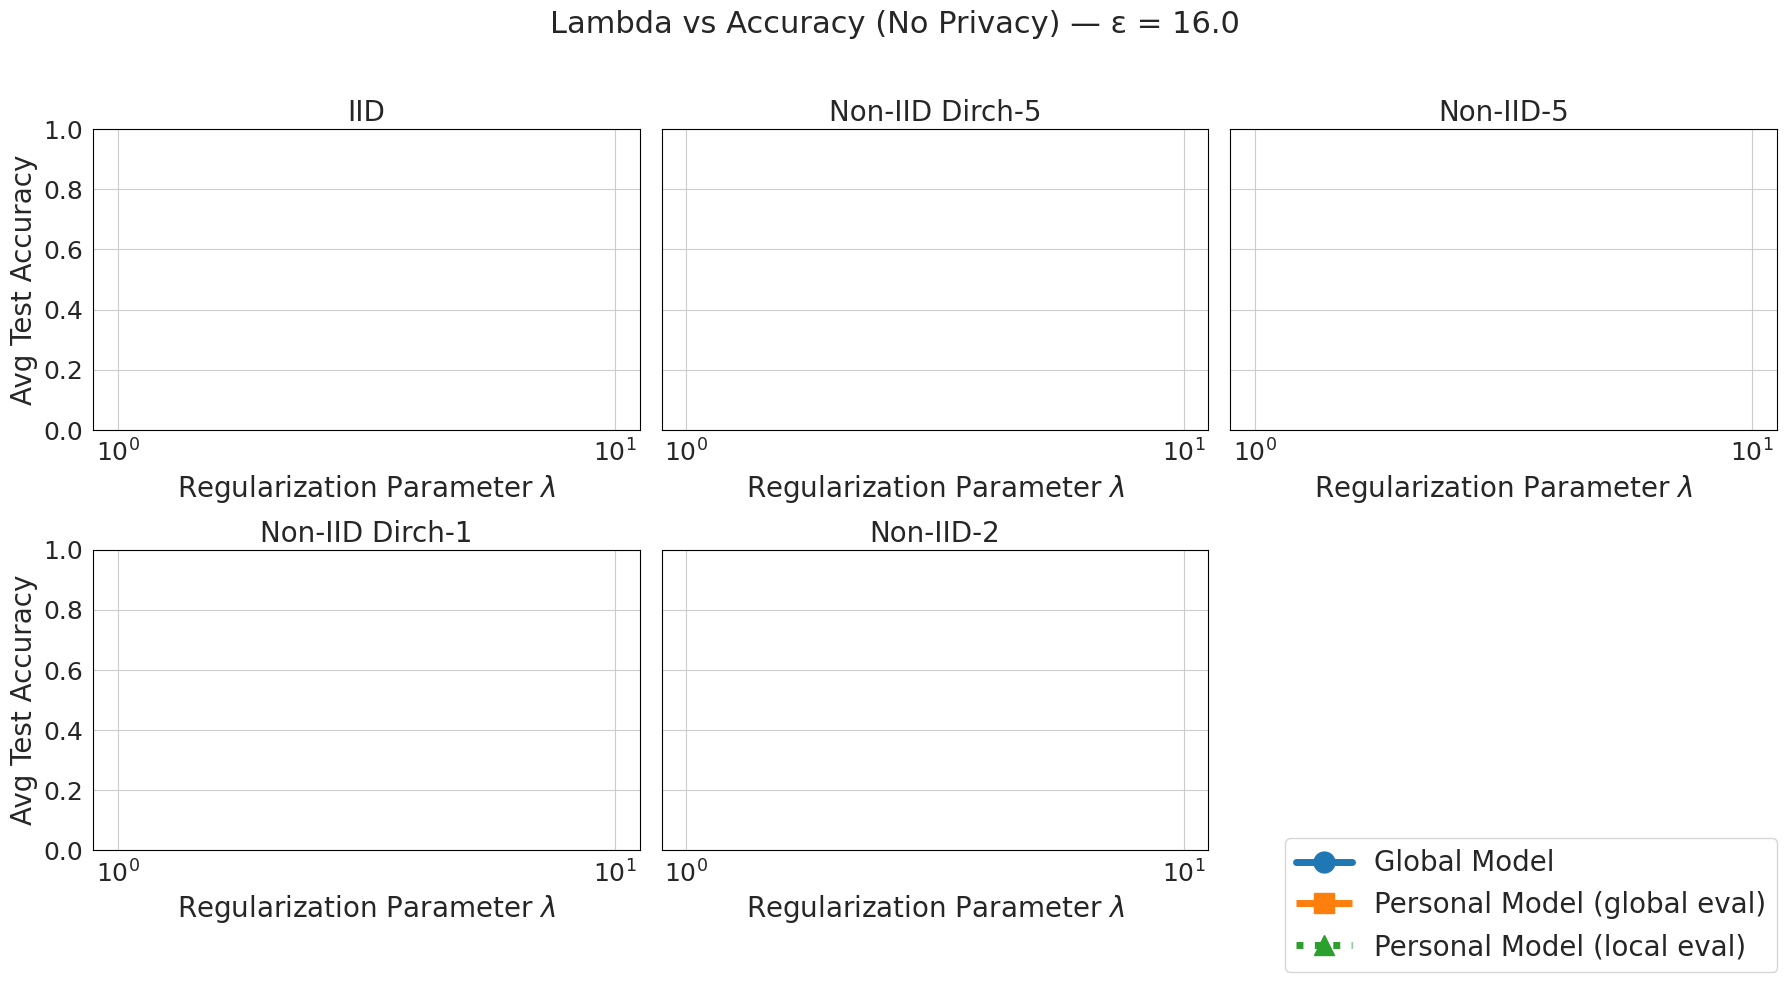

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor': 'black'})

methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global Model',
    'pooled': 'Personal Model (global eval)',
    'personal': 'Personal Model (local eval)'
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',
    'pooled': '--',
    'personal': ':'
}

marker_map = {
    'global': 'o',
    'pooled': 's',
    'personal': '^'
}

offset_map = {
    'global': 1.0,
    'pooled': 0.96,
    'personal': 1.10
}

num_steps = 15

# =========================
# datasets setup
# =========================
if DATASET == "heart_disease":
    datasets = ["niid_10_5"]
    dataset_names = {"niid_10_5": "Non_IID"}
else:
    datasets = [
        "iid_10",
        "niid_dir_5",
        "niid_10_5",
        "niid_dir_1",
        "niid_10_2",
    ]
    dataset_names = {
        'iid_10': 'IID',
        'niid_10_2': 'Non-IID-2',
        'niid_10_5': 'Non-IID-5',
        'niid_dir_1': 'Non-IID Dirch-1',
        'niid_dir_5': 'Non-IID Dirch-5',
    }

# =========================
# GET ALL EPSILONS
# =========================
all_epsilons = sorted(
    set().union(*[df['e'].unique() for df in all_results])
)

print("Epsilons found:", all_epsilons)

# =========================
# LOOP OVER EPSILON
# =========================
for eps in all_epsilons:

    fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
    axs = axs.flatten()

    

    for d_idx, ds in enumerate(datasets):

        ax = axs[d_idx]

        df = all_results[d_idx]
        df['e'] = df['e'].astype(str)
        eps = str(eps)

        # =========================
        # FILTER BY EPSILON
        # =========================
        df = df[df['e'] == eps]

        df = df[df['num_personal_steps'] == num_steps]
        df['lambda'] = df['lambda'].astype(float)

        for method in methods:

            df_m = df[df['type'] == method]

            if len(df_m) == 0:
                continue

            df_m = df_m.sort_values(by='lambda')

            x = df_m['lambda'].values * offset_map[method]

            ax.plot(
                x,
                df_m['mean_perf'],
                label=method_labels[method],
                linestyle=linestyle_map[method],
                marker=marker_map[method],
                color=colors[method],
                linewidth=5,
                markersize=15
            )

        ax.set_xscale('log')
        ax.set_title(dataset_names[ds], fontsize=20)
        ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=20)
        ax.tick_params(axis='both', labelsize=18)

        if d_idx == 0 or d_idx == 3:
            ax.set_ylabel("Avg Test Accuracy", fontsize=20)
            ax.set_ylim(0.94, 1)
        else:
            ax.set_ylim(0, 1)

        ax.grid(True)

    # remove empty subplot
    fig.delaxes(axs[5])

    # shared legend
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower right', fontsize=20)

    fig.suptitle(f"Lambda vs Accuracy (No Privacy) — ε = {eps}", fontsize=22)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

In [48]:

from myopacus.accountants.rpdp_utils import GENERATE_EPSILONS_FUNC
import numpy as np
import pandas as pd

DATASET = "heart_disease"   # change to "fashion_mnist" when needed

all_results = []

data_types= ["niid_10_5"]

for dt in data_types:
    results_dir = f"./fed_{DATASET}/{dt}/ditto/"
    file_name = f"{dt}_results_ditto_unidp_{DATASET}.csv"

    path = os.path.join(results_dir, file_name)

    print(f"Loading: {path}")  # optional debug
    all_results.append(pd.read_csv(path))


Loading: ./fed_heart_disease/niid_10_5/ditto/niid_10_5_results_ditto_unidp_heart_disease.csv


Selected epsilons: ['0.1', '0.5', '1.0', '4.0', '8.0']


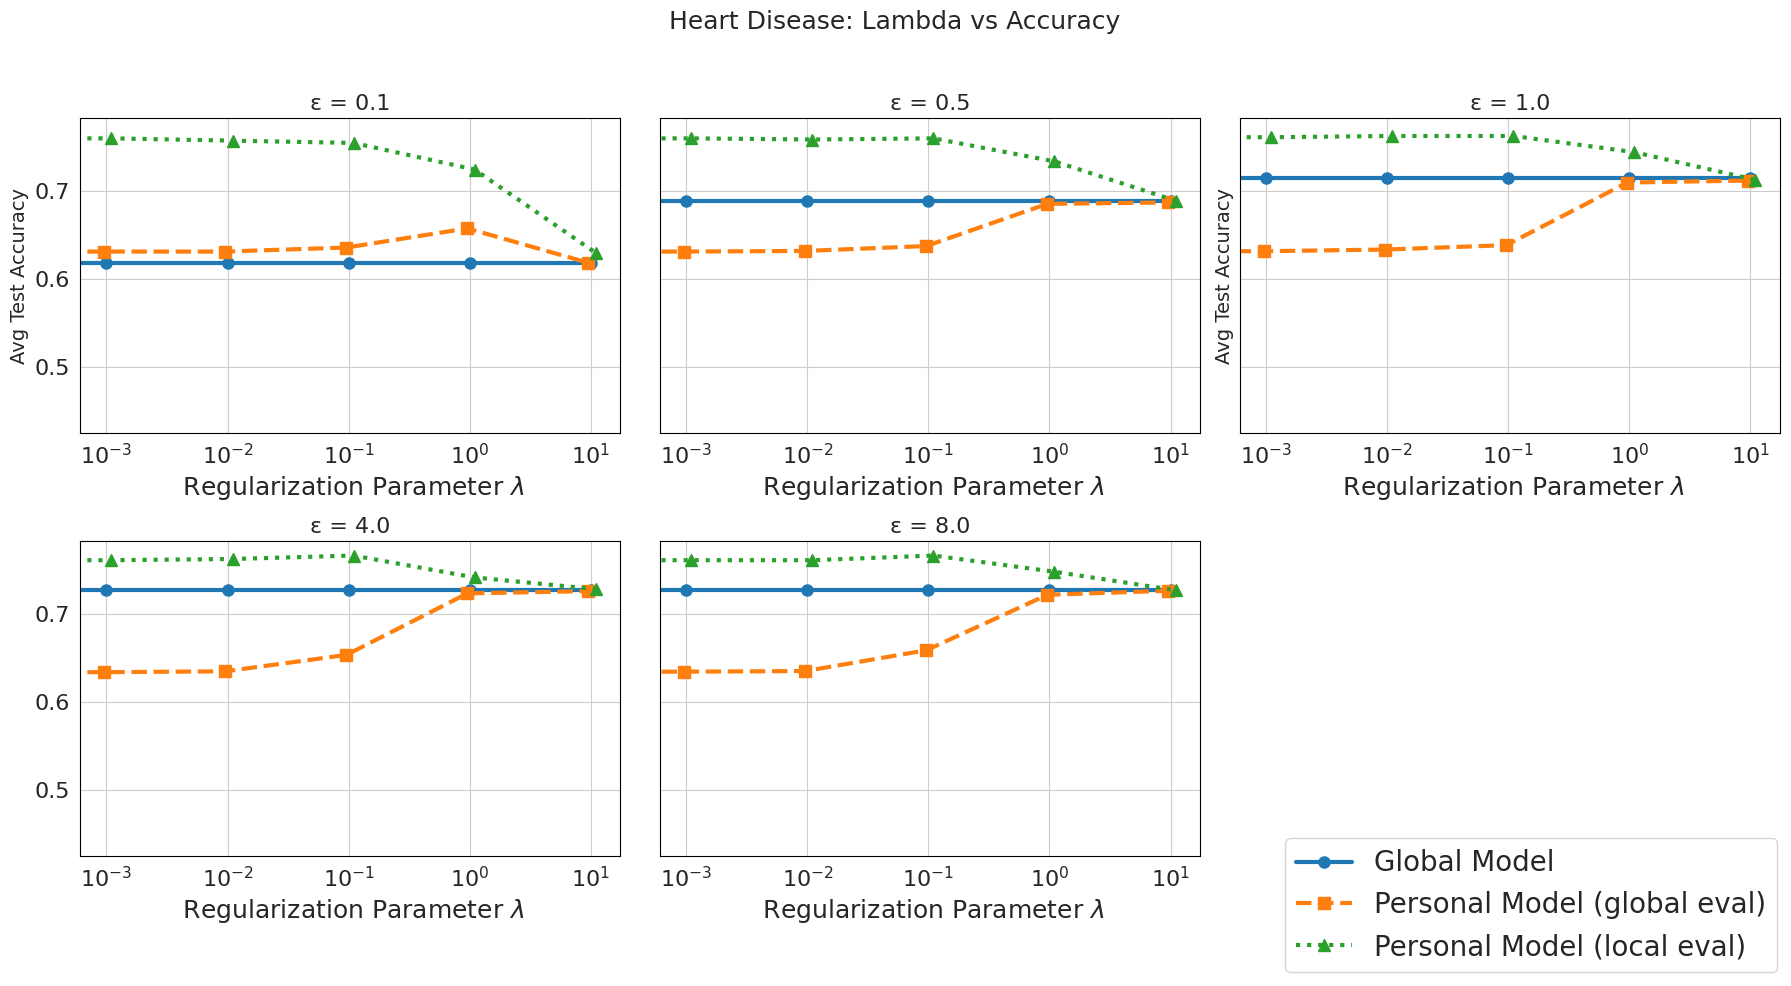

In [56]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid', {'axes.linewidth': 1, 'axes.edgecolor': 'black'})

methods = ['global', 'pooled', 'personal']

method_labels = {
    'global': 'Global Model',
    'pooled': 'Personal Model (global eval)',
    'personal': 'Personal Model (local eval)'
}

colors = {
    'global': 'tab:blue',
    'pooled': 'tab:orange',
    'personal': 'tab:green'
}

linestyle_map = {
    'global': '-',
    'pooled': '--',
    'personal': ':'
}

marker_map = {
    'global': 'o',
    'pooled': 's',
    'personal': '^'
}

offset_map = {
    'global': 1.0,
    'pooled': 0.96,
    'personal': 1.10
}

num_steps = 15

# =========================
# DATA
# =========================
df = all_results[0].copy()  # heart_disease

df['e'] = df['e'].astype(str)
df['lambda'] = df['lambda'].astype(float)

dataset_name = "Heart Disease"

# =========================
# EPSILONS
# =========================
all_epsilons = sorted(df['e'].unique())
selected_indices = [0, 1, 2, 4,5]
selected_eps = [all_epsilons[i] for i in selected_indices if i < len(all_epsilons)]

print("Selected epsilons:", selected_eps)

# =========================
# SUBPLOTS (2x2)
# =========================


fig, axs = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axs = axs.flatten()

# =========================
# LOOP OVER EPSILONS
# =========================
for i, eps in enumerate(selected_eps):

    ax = axs[i]

    df_eps = df[
        (df['e'] == eps) &
        (df['num_personal_steps'] == num_steps)
    ].copy()

    for method in methods:

        df_m = df_eps[df_eps['type'] == method]

        if len(df_m) == 0:
            continue

        df_m = df_m.sort_values(by='lambda')

        x = df_m['lambda'].values * offset_map[method]

        ax.plot(
            x,
            df_m['mean_perf'],
            label=method_labels[method],
            linestyle=linestyle_map[method],
            marker=marker_map[method],
            color=colors[method],
            linewidth=3,
            markersize=8
        )

    # remove empty subplot
    
    ax.set_xscale('log')
    ax.set_title(f"ε = {eps}", fontsize=16)
    ax.set_xlabel(r" Regularization Parameter $\lambda$", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(True)

    if i == 0 or i == 2:
        ax.set_ylabel("Avg Test Accuracy", fontsize=14)

# =========================
# ONE LEGEND FOR ALL
# =========================
fig.delaxes(axs[5])
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', ncol=1, fontsize=20)

fig.suptitle(f"{dataset_name}: Lambda vs Accuracy", fontsize=18)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()